In [54]:
#import libraries
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pickle 

In [55]:
#load data
path = os.getcwd()
data_path = os.path.join(path, 'database')
os.listdir(path)
os.listdir(data_path)

['full_x_donations.parquet',
 '.DS_Store',
 'outcomes.parquet',
 'full_x_outcomes.parquet',
 'x_donations_agg.parquet',
 'donations.parquet',
 'sampleSubmission.csv',
 'donations.csv',
 'resources.csv',
 'data.csv',
 'full_y.parquet',
 'essay_nfunded_essay',
 'essay_funded_essay',
 'outcomes.csv',
 'essays.csv',
 'projects.csv']

In [57]:
data = pd.read_csv(os.path.join(data_path, 'data.csv'))
data.head()
data.info()
data.describe()

/var/folders/8g/fjg76_9d66jffp3b0xnmcfyh0000gn/T/ipykernel_1774/1632273428.py:1: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(data_path, 'data.csv'))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 578479 entries, 0 to 578478
Data columns (total 26 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   projectid                               578479 non-null  object 
 1   school_state                            523790 non-null  object 
 2   school_metro                            523741 non-null  object 
 3   school_magnet                           513504 non-null  object 
 4   school_nlns                             512276 non-null  object 
 5   school_kipp                             511166 non-null  float64
 6   school_charter_ready_promise            511166 non-null  float64
 7   teacher_teach_for_america               511166 non-null  float64
 8   teacher_ny_teaching_fellow              511166 non-null  float64
 9   primary_focus_subject                   511166 non-null  object 
 10  primary_focus_area                      5111

,school_kipp,school_charter_ready_promise,teacher_teach_for_america,teacher_ny_teaching_fellow,total_price_excluding_optional_support,total_price_including_optional_support,students_reached,eligible_double_your_impact_match,eligible_almost_home_match,fully_funded,students_reached_scaled
count,511166.000000,511166.000000,511166.000000,511166.000000,511166.000000,511166.000000,511166.000000,511166.000000,511166.000000,511166.000000,498647.000000
mean,0.006828,0.004951,0.060888,0.019244,510.434284,607.114544,61.046709,0.280404,0.061143,0.703599,0.002934
std,0.082346,0.070192,0.239125,0.137382,752.585133,900.018435,65.698444,0.449197,0.239592,0.456670,1.001782
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-0.913968
25%,0.000000,0.000000,0.000000,0.000000,266.290000,316.890000,22.000000,0.000000,0.000000,0.000000,-0.593989
50%,0.000000,0.000000,0.000000,0.000000,410.000000,487.070000,30.000000,0.000000,0.000000,1.000000,-0.472092
75%,0.000000,0.000000,0.000000,0.000000,578.080000,687.200000,80.000000,1.000000,0.000000,1.000000,0.289763
max,1.000000,1.000000,1.000000,1.000000,97974.780000,119481.440000,399.000000,1.000000,1.000000,1.000000,5.150398


In [7]:
essay = data.loc[:,['projectid','short_description','need_statement','essay','fully_funded']]
essay["shortd"] = essay.short_description.str.len()
essay["essayd"] = essay.essay.str.len()

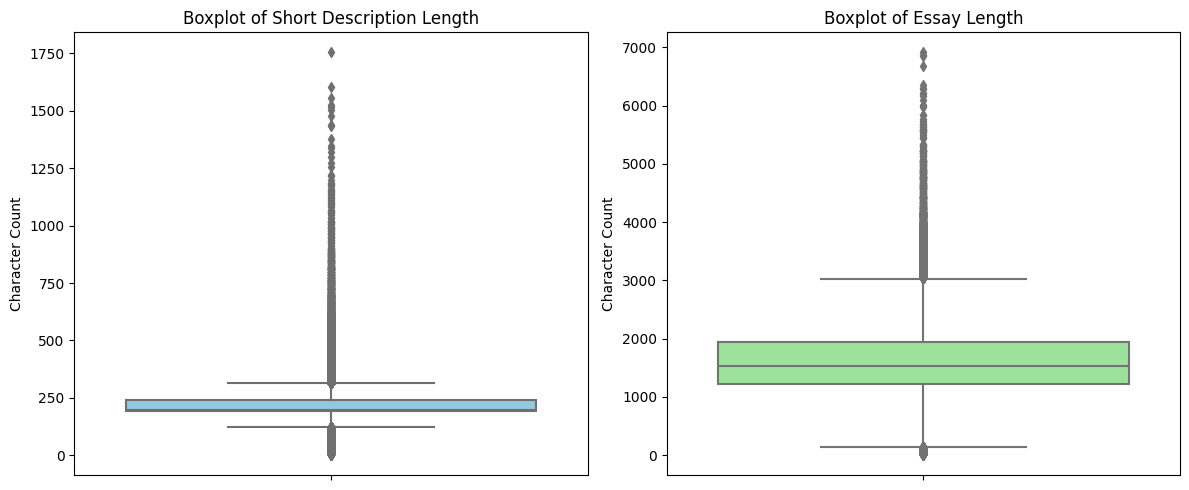

In [10]:
essay.loc[:,["shortd","essayd"]].describe()

df_plot = essay[["shortd", "essayd"]].melt(var_name="Text Type", value_name="Length")


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot for short description
sns.boxplot(y=essay["shortd"], ax=axes[0], color='skyblue')
axes[0].set_title("Boxplot of Short Description Length")
axes[0].set_ylabel("Character Count")

# Boxplot for essay
sns.boxplot(y=essay["essayd"], ax=axes[1], color='lightgreen')
axes[1].set_title("Boxplot of Essay Length")
axes[1].set_ylabel("Character Count")

plt.tight_layout()
plt.show()

In [13]:
funded_mask = essay['fully_funded'] == 1
non_funded_mask = essay['fully_funded'] == 0
funded_essay = essay[funded_mask]
nfunded_essay = essay[non_funded_mask]


funded_essay.to_csv(os.path.join(data_path, 'essay_funded_essay'))
nfunded_essay.to_csv(os.path.join(data_path, 'essay_nfunded_essay'))

In [53]:
essay['fully_funded'].value_counts()

fully_funded
1.0    359656
0.0    151510
Name: count, dtype: int64

Read TF, TF-IDF of funded and nfunded short_description from pickle

In [ ]:
# %run essay_text_preprocess.py

In [61]:
pickle_path = os.path.join('essays_processed_data_named', 'full_processed_features.pkl')
with open(pickle_path, 'rb') as f:
    loaded_processed_data = pickle.load(f)

print("\nLoaded processed features:")

labels = loaded_processed_data.get('labels')

tf_vectorizer = loaded_processed_data['all_essays_tf']['vectorizer']
tfidf_vectorizer = loaded_processed_data['all_essays_tfidf']['vectorizer']

tf_matrix = loaded_processed_data['all_essays_tf']['matrix']
tfidf_matrix = loaded_processed_data['all_essays_tfidf']['matrix']


print("TF matrix shape:", tf_matrix.shape)
print("TFIDF matrix shape:", tfidf_matrix.shape)
print("Labels shape:", labels.shape)


Loaded processed features:
TF matrix shape: (20000, 1000)
TFIDF matrix shape: (20000, 1000)
Labels shape: (20000,)


# LDA Pipeline

In [75]:
from sklearn.decomposition import LatentDirichletAllocation

vocab_size = 1000
n_components = 10
def lda_analysis(df,n_components):
    lda = LatentDirichletAllocation(n_components=n_components, random_state=0)
    lda.fit(df)
    lda.components_.shape
    topic_word_distributions = np.array([row / row.sum() for row in lda.components_])
    return lda, topic_word_distributions

In [76]:
num_top_words = 20

def print_top_words(topic_word_distributions, num_top_words, vectorizer):
    vocab = vectorizer.get_feature_names_out()
    num_topics = len(topic_word_distributions)
    print('Displaying the top %d words per topic and their probabilities within the topic...' % num_top_words)
    print()
    for topic_idx in range(num_topics):
        print('[Topic ', topic_idx, ']', sep='')
        sort_indices = np.argsort(-topic_word_distributions[topic_idx])
        for rank in range(num_top_words):
            word_idx = sort_indices[rank]
            print(vocab[word_idx], ':',
                  topic_word_distributions[topic_idx, word_idx])
        print()

In [84]:
def project_topic_distribution(lda, tfidf, labels):
    doc_topic_matrix = lda.transform(tfidf)
    print(doc_topic_matrix.shape)
    doc_dominant_topic = np.argmax(doc_topic_matrix, axis=1)
    label_project_topic = pd.DataFrame({
        'topic': doc_dominant_topic,
        'fully_funded': labels
    })
    topic_funding_table = pd.crosstab(
        label_project_topic['topic'],
        label_project_topic['fully_funded'],
        normalize='index'  
    )
    print(topic_funding_table)

    topic_counts = label_project_topic['topic'].value_counts().sort_index()
    topic_percentages = topic_counts / len(label_project_topic)

    # 构建新的 yticklabels：加入数量和百分比
    topic_labels = [
        f"Topic {i} ({count} docs, {percent:.1%})"
        for i, (count, percent) in enumerate(zip(topic_counts, topic_percentages))
    ]

    # 画图
    plt.figure(figsize=(20, 10))
    ax = sns.heatmap(topic_funding_table, annot=True, cmap='Blues', cbar=True, fmt='.2f', linewidths=0.5)
    colorbar = ax.collections[0].colorbar
    colorbar.set_label("Proportion")
    plt.title("Topic Distribution for Fully Funded and Funded Projects")
    plt.xlabel('Funding Status')
    plt.ylabel('Topic')

    # 设置新的 y 轴标签
    plt.yticks(ticks=np.arange(len(topic_labels)) + 0.5, labels=topic_labels, rotation=0)

    # plt.tight_layout()
    plt.show()


    return topic_funding_table


In [78]:
lda_model, topic_word_distributions = lda_analysis(tfidf_matrix, n_components=n_components)
print_top_words(topic_word_distributions, num_top_words=20, vectorizer=tfidf_vectorizer)

Displaying the top 20 words per topic and their probabilities within the topic...

[Topic 0]
supply : 0.011111448307398724
school : 0.01091302467507006
classroom : 0.009839308996146871
rug : 0.009140311496108083
pencil : 0.009079120308077082
need : 0.008556729996269783
help : 0.008403808886549772
work : 0.0076783531786227726
paper : 0.007516794869954405
learn : 0.007497553454560551
sit : 0.006902256269248411
year : 0.0068570674694242734
carpet : 0.006800706162272031
child : 0.006755617583257382
time : 0.006510824483578859
write : 0.0065024756081063645
writing : 0.006349852606094789
place : 0.006296911138816693
space : 0.005722995798591983
material : 0.005622748196372424

[Topic 1]
read : 0.02311693461382032
listen : 0.01855628488907289
listening : 0.018350259339740507
book : 0.016190377570180554
center : 0.015976245132010243
reading : 0.01504817819088569
story : 0.013578654462301904
reader : 0.01028302316586674
language : 0.00948760170197161
fluency : 0.00914845620786954
english : 0.00

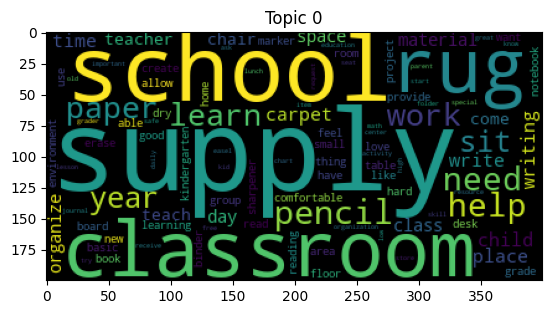

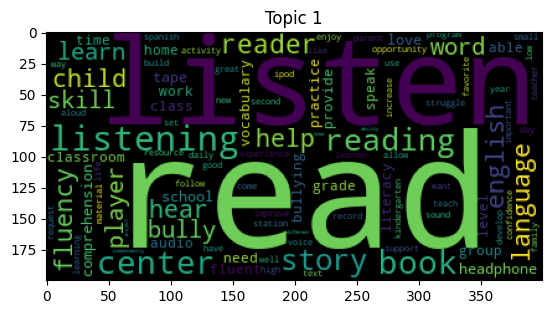

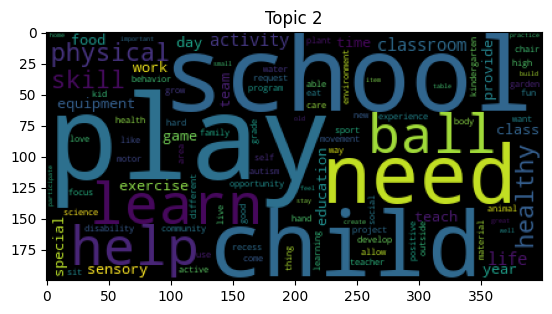

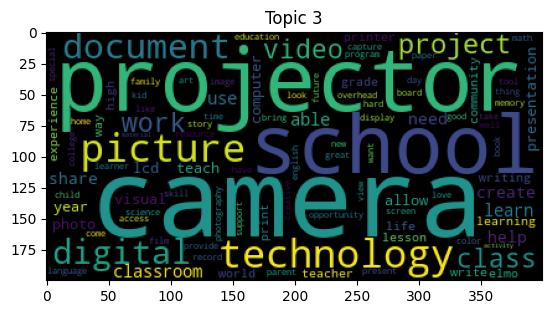

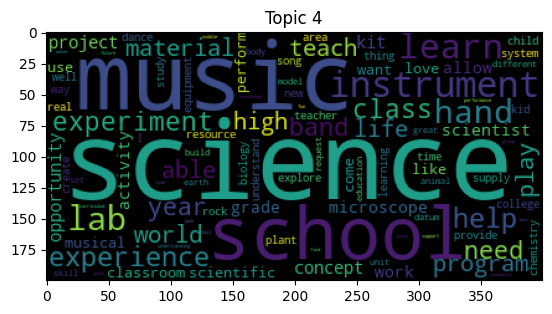

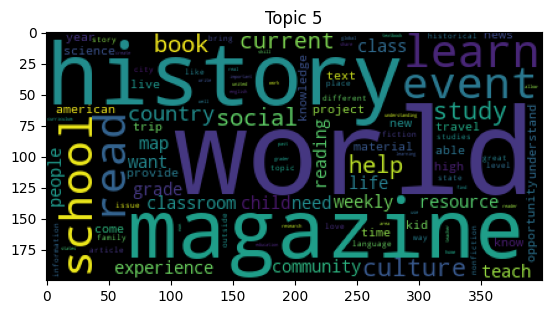

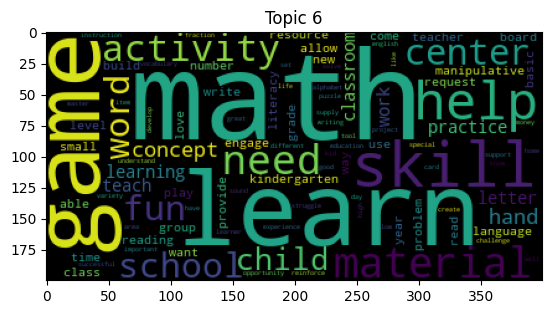

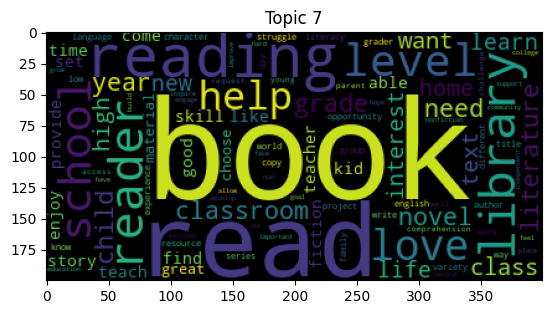

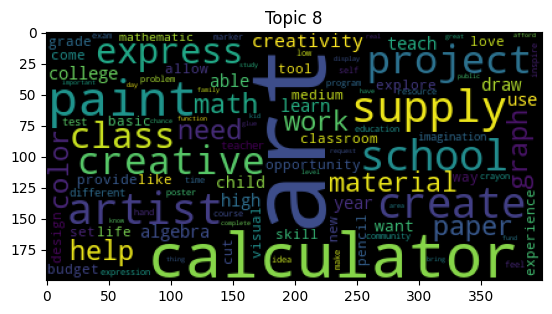

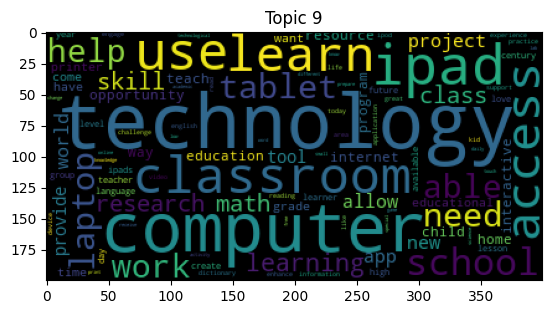

In [87]:
from wordcloud import WordCloud

num_max_word_cloud_words = 100

vocab = tfidf_vectorizer.get_feature_names_out()
num_topics = len(topic_word_distributions)

for topic_idx in range(num_topics):
    wc = WordCloud(max_words=num_max_word_cloud_words)
    wc.generate_from_frequencies(dict(zip(vocab, topic_word_distributions[topic_idx])))
    plt.figure()
    plt.imshow(wc)
    plt.title('Topic %d' % topic_idx)

(20000, 10)
fully_funded         0         1
topic                           
0             0.495342  0.504658
1             0.525814  0.474186
2             0.472648  0.527352
3             0.606939  0.393061
4             0.424961  0.575039
5             0.423623  0.576377
6             0.484156  0.515844
7             0.451671  0.548329
8             0.440252  0.559748
9             0.586629  0.413371


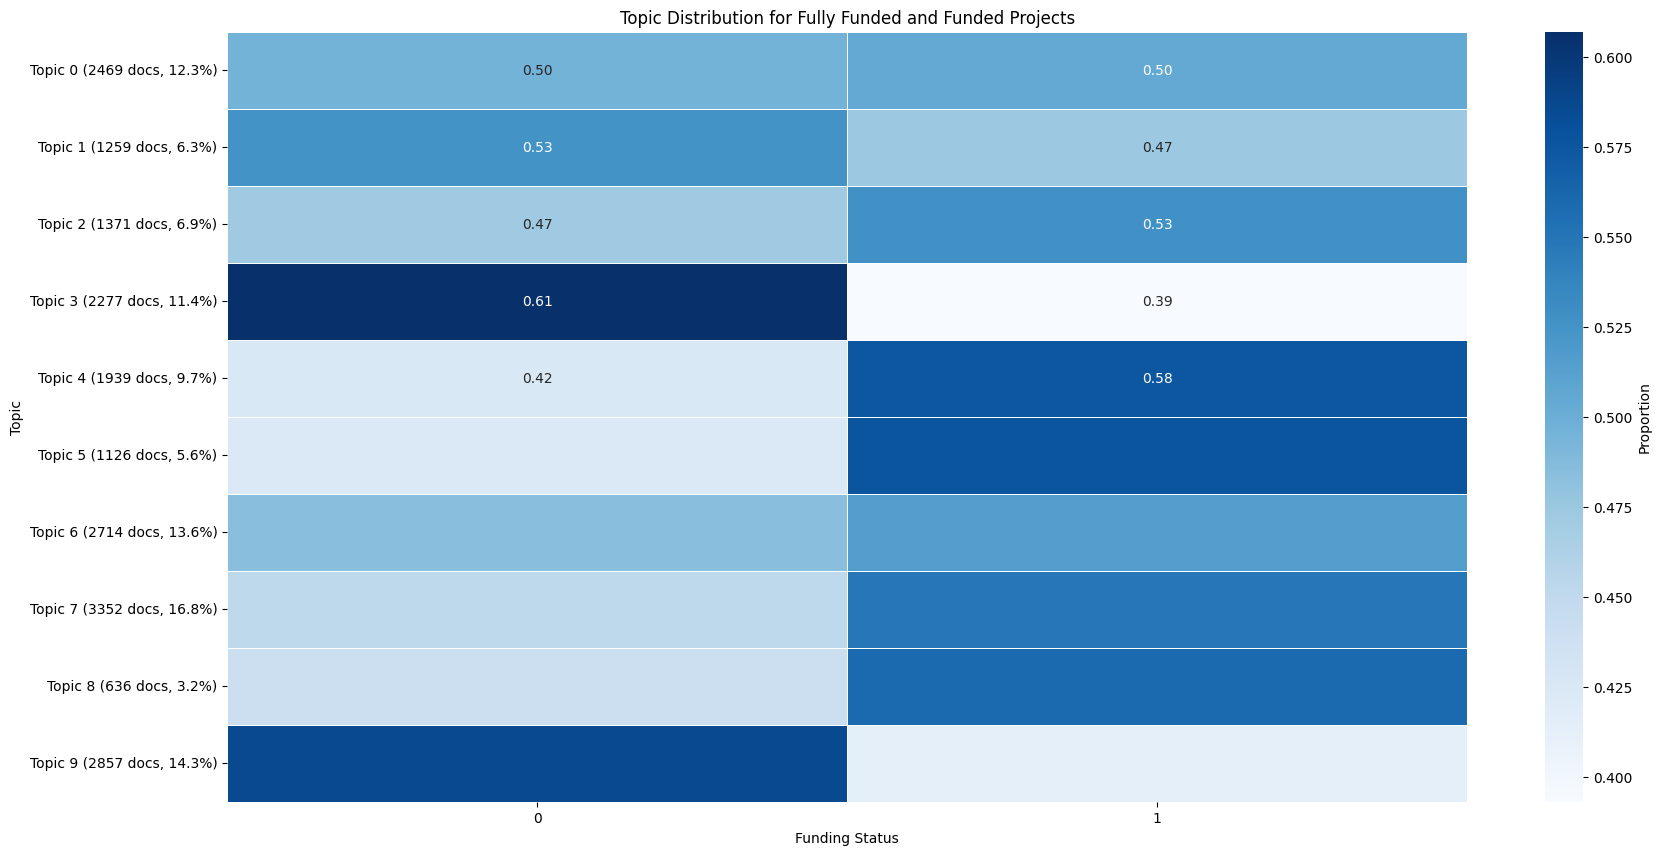

fully_funded,0,1
topic,,
0,0.495342,0.504658
1,0.525814,0.474186
2,0.472648,0.527352
3,0.606939,0.393061
4,0.424961,0.575039
5,0.423623,0.576377
6,0.484156,0.515844
7,0.451671,0.548329
8,0.440252,0.559748


In [86]:
project_topic_distribution(lda_model, tfidf_matrix, labels)